In [1]:
%load_ext autoreload
%autoreload 2

from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from aux import format_plot
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp

plt.rcParams['font.family'] = 'Helvetica'

In [2]:
class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
        deriv_sign=1,
    ):
        """
        Initialize the 2D linear system
        
        Parameters:
        u_func: function that takes time t and returns input vector [u1(t), u2(t)]
                or array-like for constant input (backward compatibility)
        tau: float, time constant parameter
        """
        # Handle both function and constant input for backward compatibility
        if callable(u_func):
            self.u_func = u_func
            self.u_constant = None
        else:
            # Convert constant input to function
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array
            self.u_constant = u_array
        self.reset_func = reset_func
            
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        self.deriv_sign = deriv_sign
        
        # Initial conditions based on your specification
        if w_11 is None:
            w_11 = 1.5 + np.random.normal(loc=0, scale=weight_perturbation)
        if w_22 is None:
            w_22 = 1.5 + np.random.normal(loc=0, scale=weight_perturbation)

        if w_12 is None:
            w_12 = (1.5 - 1) + np.random.normal(loc=0, scale=weight_perturbation)
        if w_21 is None:
            w_21 = (1.5 - 1) + np.random.normal(loc=0, scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                           [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = w_inh
        
        # x_j = 1 - x_i (assuming some initial values)
        self.x0 = np.clip(np.array([x1_init, x2_init]) + np.random.normal(loc=np.zeros(2), scale=np.ones(2) * noise_std), 0, 1)
    
    def system_dynamics(self, state, t):
        """
        Define the system of differential equations
        
        state = [x1, x2, w11, w12, w21, w22]
        """
        x1, x2, w11, w12, w21, w22 = state
        
        # Current state vector and weight matrix
        x = np.clip(np.array([x1, x2]), 0, None)
        W = np.array([[w11, w12], [w21, w22]])

        w_inh_1 = self.w_inh[0]
        w_inh_2 = self.w_inh[1]
        w_inh = np.array([[w_inh_1, w_inh_1], [w_inh_2, w_inh_2]])

        # Get time-varying input
        u_t = np.array(self.u_func(t))
        reset_t = np.array(self.reset_func(t))
        
        # State dynamics: dx/dt = Wx - x + u(t) (now time-varying)
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where(np.logical_and(x <= 0, dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt
        
        # Weight dynamics: dw_ij/dt = tau^2 * [dx_i/dt * x_j - x_i * dx_j/dt] - x_i(1-x_i) + x_j(1-x_j)
        deriv_sign = self.deriv_sign
        homeo_rate = self.homeo_rate
        input_off = np.isclose(np.array(self.u_func(t+10)), 0) | np.isclose(np.array(self.u_func(t)), 0)
        if self.learning_rate == 0 or input_off.all():
            dw11_dt, dw12_dt, dw21_dt, dw22_dt = 0, 0, 0, 0
        else:
            z = 0.05 * np.maximum(u_t - 0.5, 0)

            dw11_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[0] - deriv_sign * dx1_dt * x[0]) + homeo_rate * (2 - w11 - w21)) + reset_t * (0.5 - w11)
            dw12_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[1] - deriv_sign * dx1_dt * x[1]) + homeo_rate * (2 - w22 - w12)) + reset_t * (0.5 - w12)
            dw21_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[0] - deriv_sign * dx2_dt * x[0]) + homeo_rate * (2 - w11 - w21)) + reset_t * (0.5 - w21)
            dw22_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[1] - deriv_sign * dx2_dt * x[1]) + homeo_rate * (2 - w22 - w12)) + reset_t * (0.5 - w22)
        
        return [dx1_dt, dx2_dt, dw11_dt, dw12_dt, dw21_dt, dw22_dt]
    
    def simulate(self, t_span, dt=0.002):
        """
        Simulate the system over time
        
        Parameters:
        t_span: tuple, (start_time, end_time)
        dt: float, time step
        """
        t = np.arange(t_span[0], t_span[1], dt)
        
        # Initial state vector
        initial_state = [self.x0[0], self.x0[1], 
                        self.W0[0,0], self.W0[0,1], self.W0[1,0], self.W0[1,1]]
        
        # Solve the ODE system
        solution = odeint(self.system_dynamics, initial_state, t)
        
        # Extract results
        x1, x2 = solution[:, 0], solution[:, 1]
        w11, w12, w21, w22 = solution[:, 2], solution[:, 3], solution[:, 4], solution[:, 5]
        
        # Also compute the input over time for plotting
        u_history = np.array([self.u_func(time) for time in t])
        
        return t, x1, x2, w11, w12, w21, w22, u_history

# Modified simulation function
def run_simulation(
    u_funcs=None,
    reset_funcs=None,
    x1_init_values=None,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_sim=(0, 200),
    weight_perturbation=0,
    color_by=None,
    reinitialize=False,
    noise_std=0,
    tau=2,
    save_path=None,
    make_cbar=False,
    w_inh=np.array([1, 1]),
    cbar_label=None,
    y_lim_1=None,
    y_lim_2=None,
    y_lim_3=None,
    y_lim_4=None,
    width=1,
    deriv_sign=1,
):
    """
    Run simulation with time-varying input
    
    Parameters:
    u_func: function that takes time t and returns [u1(t), u2(t)]
           if None, uses constant input [0.5, 0.5]
    """
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)

    if x1_init_values is None:
        x1_init_values = np.clip(np.linspace(0.05, 0.95, 10), 0, 1)

    x2_init_values = 1 - x1_init_values

    x1_init_values = np.clip(x1_init_values + np.random.normal(scale=np.ones(x1_init_values.shape[0]) * noise_std), 0, 1)
    x2_init_values = np.clip(x2_init_values + np.random.normal(scale=np.ones(x2_init_values.shape[0]) * noise_std), 0, 1)

    # Default to constant input for backward compatibility
    if u_funcs is None:
        u_funcs = [lambda t: [0.5, 0.5]] * len(x1_init_values)
    if reset_funcs is None:
        reset_funcs = [lambda t: 0] * len(x1_init_values)

    cmap = sns.color_palette("magma", as_cmap=True)
    if color_by is None:
        colors = cmap(0.5 * (1 + x1_init_values - x2_init_values))
    else:
        m = np.abs(color_by).max()
        colors = cmap(0.5 * (1 + color_by/m))
    
    # Storage for all simulations
    all_results = []
    all_results_2 = []
    
    # Set up the plot - now 4 rows, 1 column
    scale = 0.6
    fig, axes = plt.subplots(4, 1, figsize=(4 * scale * width, 14 * scale))
    
    print(f"Running simulations for {len(x1_init_values)} initial conditions...")

    axes[0].plot([1, 0], [0, 1], '--', c='gray')
    
    for i, (x1_init, x2_init, color) in enumerate(zip(x1_init_values, x2_init_values, colors)):
        # Create system with this initial condition and time-varying input
        system = LinearSystem(u_funcs[i], reset_funcs[i], tau, x1_init=x1_init, x2_init=x2_init, noise_std=0, 
                            weight_perturbation=weight_perturbation, 
                            learning_rate=learning_rate, homeo_rate=homeo_rate, alpha=alpha, w_inh=w_inh,
                            deriv_sign=deriv_sign)
        
        # Simulate
        t, x1, x2, w11, w12, w21, w22, u_history = system.simulate(t_sim, dt=0.002)
        all_results.append((t, x1, x2, w11, w12, w21, w22, u_history))
        
        # Phase portrait (position 0)
        axes[0].plot(x1, x2, color=color, linewidth=2, alpha=0.2)
        axes[0].scatter(x1[0], x2[0], marker='o', edgecolor=color, facecolor='none', s=50, alpha=0.8)
        axes[0].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
        
        # State variables (position 1 - original (0,0) plot)
        axes[1].plot(t, x1 - x2, color=color, linewidth=1.5, alpha=0.8)

        axes[2].plot(t, w11, color=color, linewidth=1.5, alpha=0.8)
        axes[2].plot(t, w22, color=color, linewidth=1.5, alpha=0.8, linestyle='--')
        
        # Off-diagonal weights (position 2)
        axes[3].plot(t, w21, color=color, linewidth=1.5, alpha=0.8)
        axes[3].plot(t, w12, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

    if make_cbar:
        norm = Normalize(vmin=(x1_init_values - x2_init_values).min(), 
        vmax=(x1_init_values - x2_init_values).max())
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.85, 0.9, 0.04, 0.07])  # [left, bottom, width, height]
        cbar_label = cbar_label if cbar_label is not None else r'$x_1 - x_2$'
        cbar = fig.colorbar(sm, cax=cbar_ax, label=cbar_label)
    
    # Configure all subplots
    axes[0].set_xlabel(r'$x_1$')
    axes[0].set_ylabel(r'$x_2$')
    # axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-0.1, 1.5)
    if not y_lim_1:
        axes[0].set_ylim(-0.1, 1.5)
    else:
        axes[0].set_ylim(*y_lim_1)
    
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel(r'$x_1 - x_2$')
    if y_lim_2:
        axes[1].set_ylim(*y_lim_2)
    # axes[1].set_ylim(-1.5, 1.5)
    # axes[1].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Diagonal weights')
    if y_lim_3:
        axes[2].set_ylim(*y_lim_3)
    # axes[1].set_ylim(0, 2)
    # axes[2].grid(True, alpha=0.3)
    
    axes[3].set_xlabel('Time')
    axes[3].set_ylabel('Off-diagonal weights')
    if y_lim_4:
        axes[3].set_ylim(*y_lim_4)
    # axes[1].set_ylim(0, 2)
    # axes[3].grid(True, alpha=0.3)

    format_plot(axes, ticklabelsize=16, axislabelsize=16)
    if make_cbar:
        format_plot(cbar.ax, bottomspine=False, topspine=False, rightspine=False, leftspine=False, ticklabelsize=16, axislabelsize=16)

    plt.tight_layout()
    plt.show()

    if save_path is not None:
        fig.savefig(save_path + '.png')
        fig.savefig(save_path + '.svg')
    
    return all_results, fig


Running simulations for 10 initial conditions...


/tmp/ipykernel_2973601/988501842.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


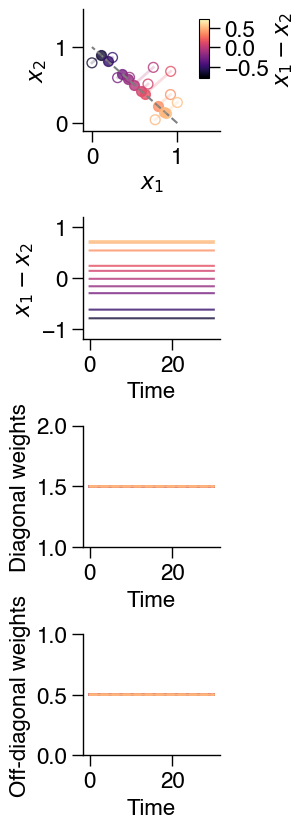

In [17]:
run_simulation(
    homeo_rate=0,
    learning_rate=0,
    seed=13,
    weight_perturbation=0,
    noise_std=0.2,
    t_sim=(0, 30),
    make_cbar=True,
    save_path='figures/handbuilt_rules/2d_handbuilt_ex_tuned',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


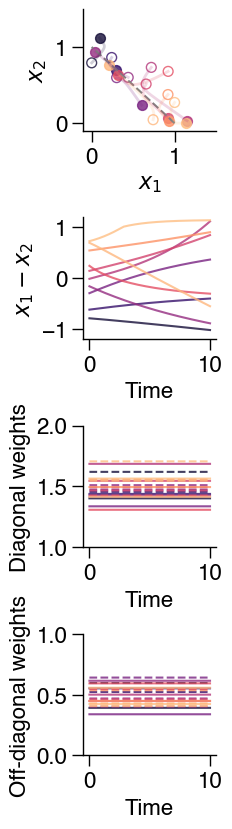

In [14]:
run_simulation(
    homeo_rate=0,
    learning_rate=0,
    seed=13,
    weight_perturbation=0.1,
    noise_std=0.2,
    t_sim=(0, 10),
    save_path='figures/handbuilt_rules/2d_handbuilt_ex_mistuned',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


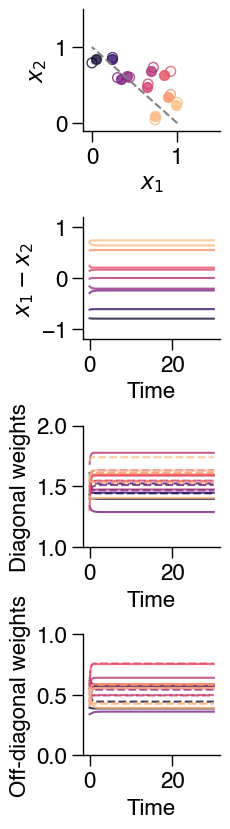

In [13]:
run_simulation(
    homeo_rate=0,
    seed=13,
    weight_perturbation=0.1,
    noise_std=0.2,
    t_sim=(0, 30),
    save_path='figures/handbuilt_rules/2d_handbuilt_ex_antihebbian',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


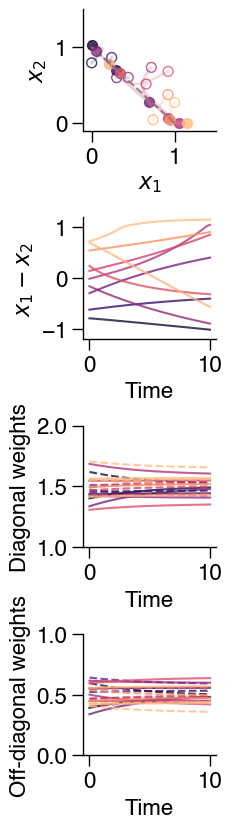

In [15]:
run_simulation(
    homeo_rate=0.1,
    tau=0,
    seed=13,
    weight_perturbation=0.1,
    noise_std=0.2,
    t_sim=(0, 10),
    save_path='figures/handbuilt_rules/2d_handbuilt_presyn',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


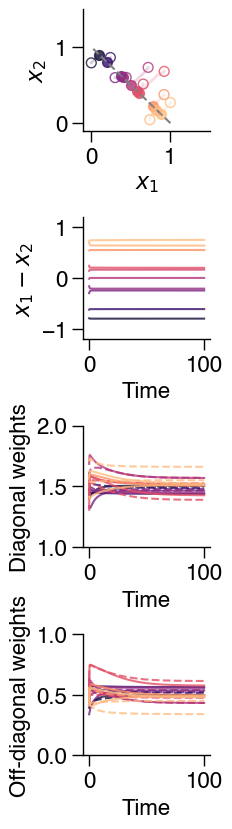

In [16]:
run_simulation(
    homeo_rate=0.1,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.1,
    noise_std=0.2,
    t_sim=(0, 100),
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...


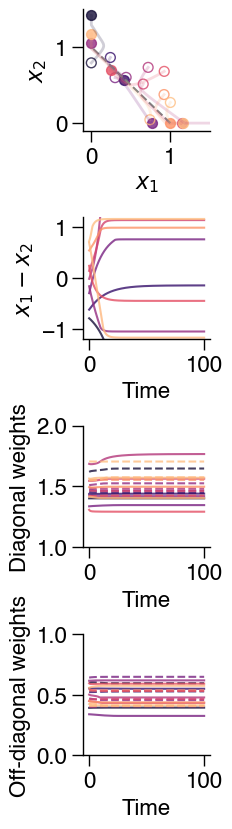

In [26]:
run_simulation(
    homeo_rate=0,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.1,
    noise_std=0.2,
    t_sim=(0, 100),
    save_path='figures/handbuilt_rules/2d_handbuilt_hebbian_presyn',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
    deriv_sign=-0.01,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]
Axes(0.85,0.9;0.04x0.07)


/tmp/ipykernel_2211897/2098429281.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


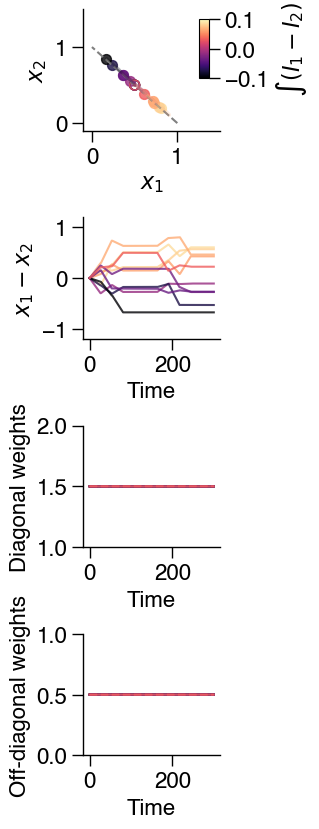

In [17]:
np.random.seed(105)
dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p < 75 or (t_p >= 150 and t_p < 225):
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.02 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    seed=13,
    weight_perturbation=0,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    make_cbar=True,
    save_path='figures/handbuilt_rules/2d_handbuilt_ex_tuned_integration',
    cbar_label=r'$\int \left(I_1 - I_2\right)$',
    y_lim_2=(-1.2, 1.2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


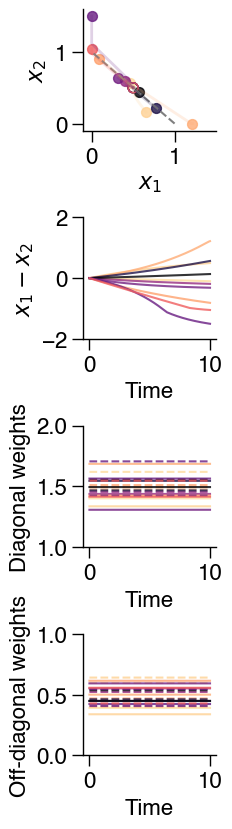

In [28]:
np.random.seed(105)
dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p < 75 or (t_p >= 150 and t_p < 225):
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.01 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 10),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_ex_mistuned_integration',
    cbar_label=r'$\Delta I_1 - I_2$',
    y_lim_1=(-0.1, 1.6),
    y_lim_2=(-2, 2),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


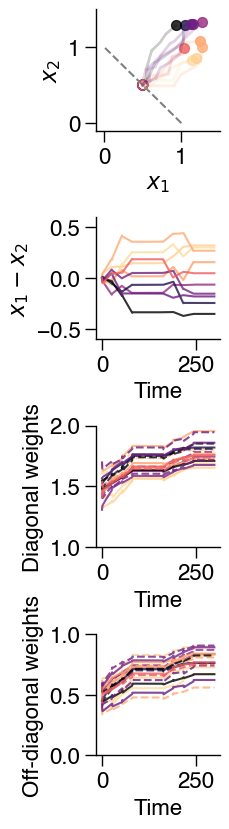

In [25]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=4,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_anithebbian_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


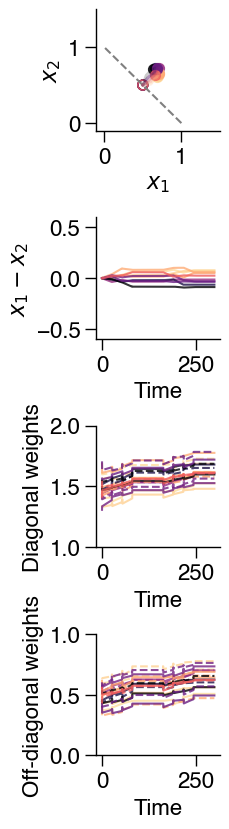

In [8]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=16,
    alpha=1,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_anithebbian_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

In [ ]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=4,
    alpha=4,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_anithebbian_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


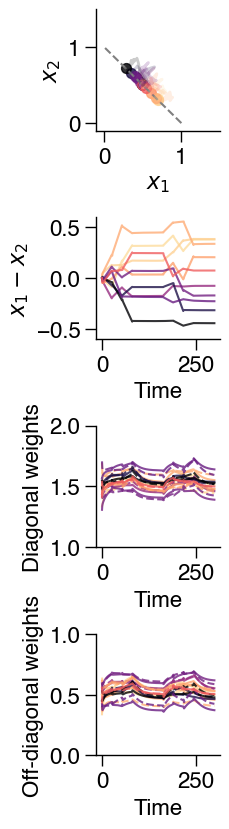

In [31]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


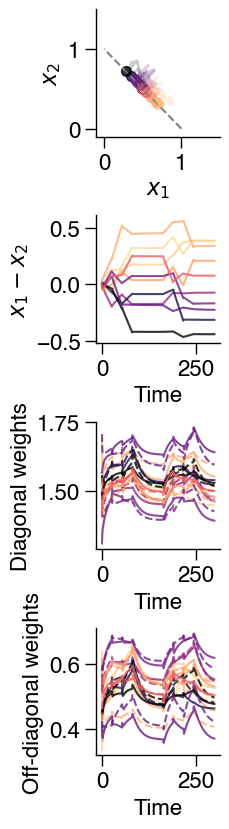

In [81]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


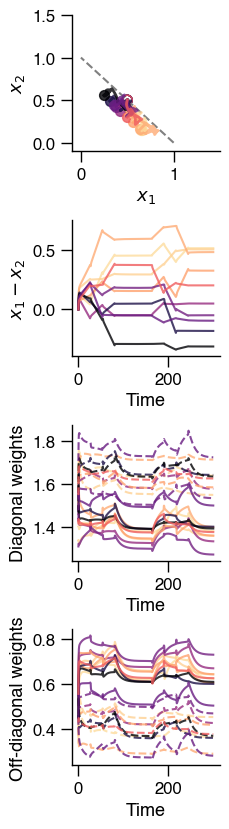

In [5]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    w_inh=np.array([1, 1.25]),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


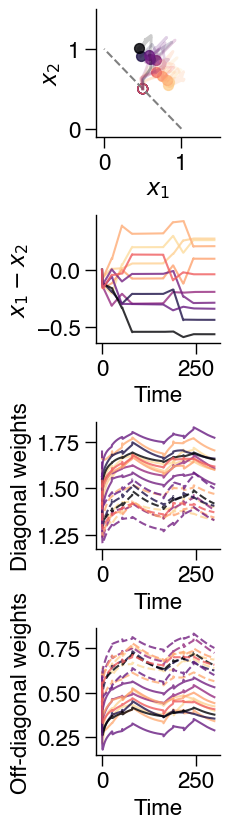

In [4]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    w_inh=np.array([1, 0.75]),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


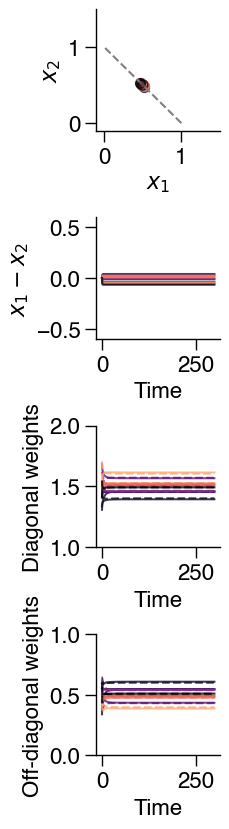

In [7]:
np.random.seed(110)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp * 0 + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_no_input_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(1, 2),
    y_lim_4=(0, 1),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


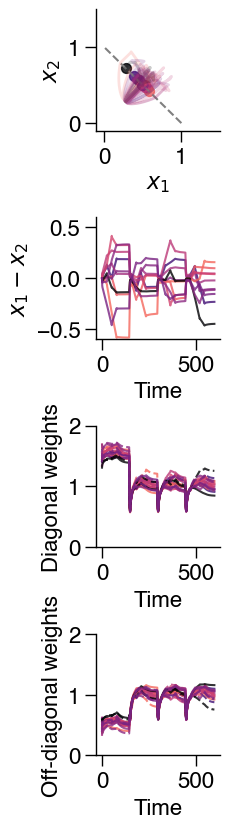

In [8]:
np.random.seed(141)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

def reset_func(t):
    t_mod = t % 150
    return (t_mod >= 145) & (t_mod < 150) & (t < 450)

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    reset_funcs=[reset_func for x in range(10)],
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0, 450 * 500:].sum() - inp[1, 450 * 500:].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-0.6, 0.6),
    y_lim_3=(0, 2),
    y_lim_4=(0, 2),
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


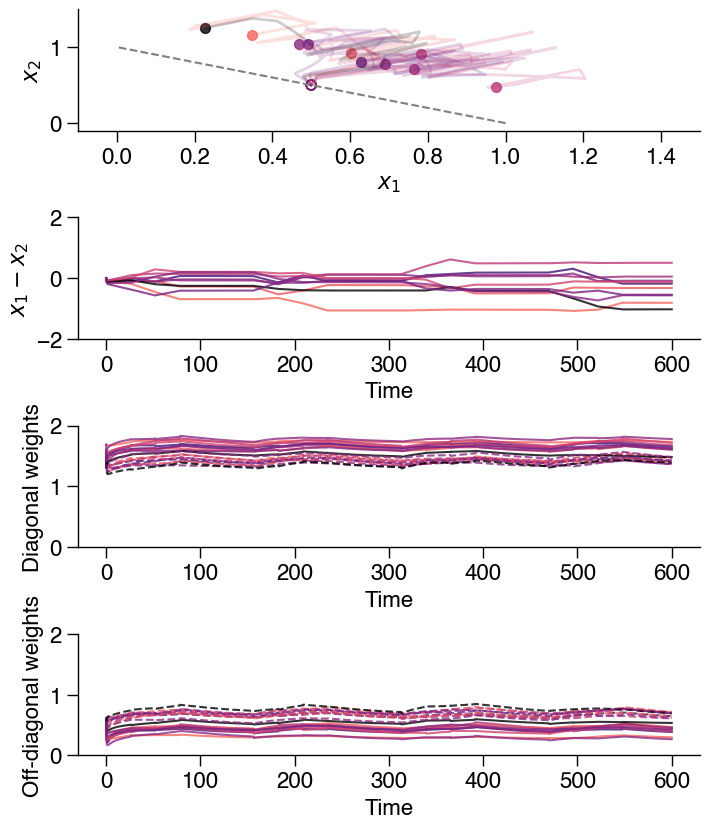

In [5]:
np.random.seed(141)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

def reset_func(t):
    return 0

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    reset_funcs=[reset_func for x in range(10)],
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0, 450 * 500:600 * 500].sum() - inp[1, 450 * 500:600 * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-2, 2),
    y_lim_3=(0, 2),
    y_lim_4=(0, 2),
    w_inh=np.array([1, 0.75]),
    width=3,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


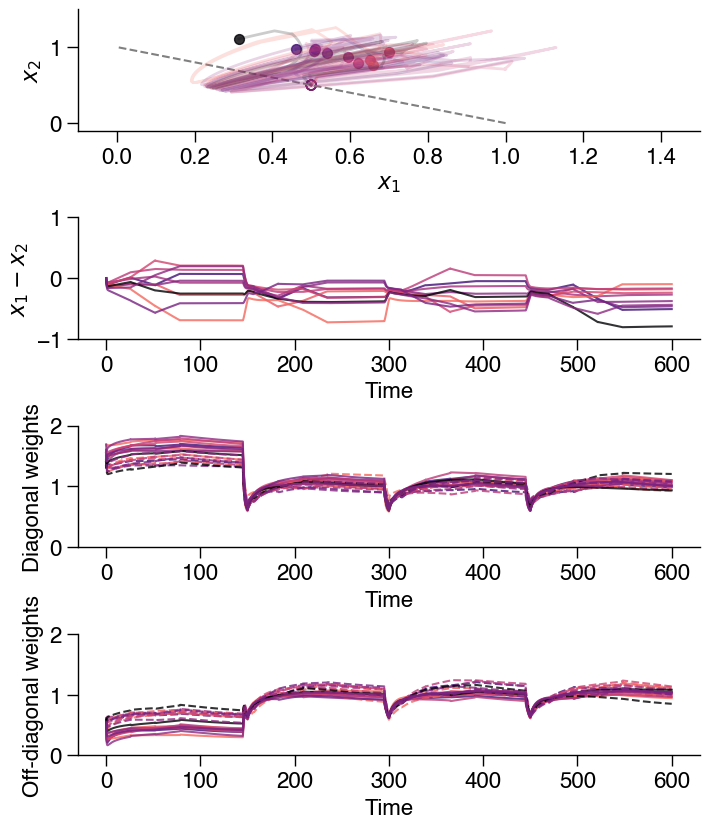

In [14]:
np.random.seed(141)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

def reset_func(t):
    t_mod = t % 150
    return (t_mod >= 145) & (t_mod < 150) & (t < 450)

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    reset_funcs=[reset_func for x in range(10)],
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0, 450 * 500:600 * 500].sum() - inp[1, 450 * 500:600 * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0, 2),
    w_inh=np.array([1, 0.75]),
    width=3,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


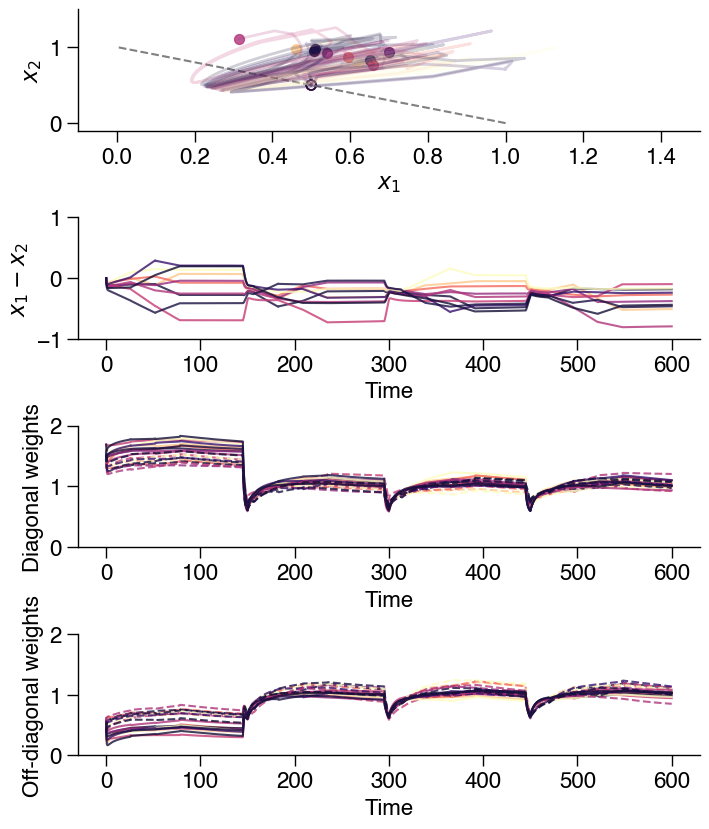

In [13]:
np.random.seed(141)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

def reset_func(t):
    t_mod = t % 150
    return (t_mod >= 145) & (t_mod < 150) & (t < 450)

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    reset_funcs=[reset_func for x in range(10)],
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0, 300 * 500:450 * 500].sum() - inp[1, 300 * 500:450 * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0, 2),
    w_inh=np.array([1, 0.75]),
    width=3,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


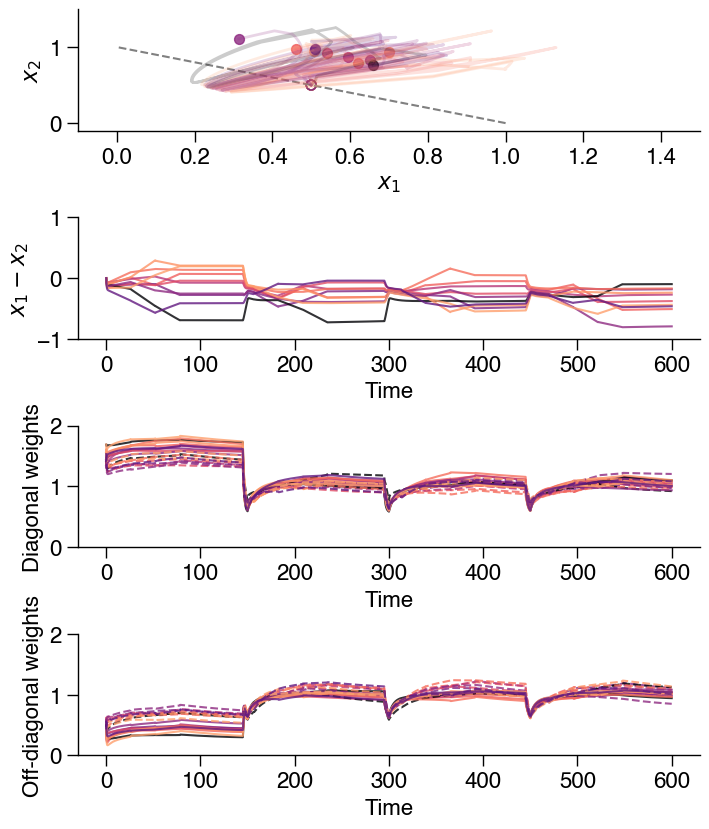

In [3]:
np.random.seed(141)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

def reset_func(t):
    t_mod = t % 150
    return (t_mod >= 145) & (t_mod < 150) & (t < 450)

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    reset_funcs=[reset_func for x in range(10)],
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0, 0 * 500:150 * 500].sum() - inp[1, 0 * 500:150 * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0, 2),
    w_inh=np.array([1, 0.75]),
    width=3,
)
None

### Change bound to depend on a single synapse

In [5]:
class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
    ):
        """
        Initialize the 2D linear system
        
        Parameters:
        u_func: function that takes time t and returns input vector [u1(t), u2(t)]
                or array-like for constant input (backward compatibility)
        tau: float, time constant parameter
        """
        # Handle both function and constant input for backward compatibility
        if callable(u_func):
            self.u_func = u_func
            self.u_constant = None
        else:
            # Convert constant input to function
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array
            self.u_constant = u_array
        self.reset_func = reset_func
            
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        
        # Initial conditions based on your specification
        if w_11 is None:
            w_11 = 1 + np.random.normal(loc=0, scale=weight_perturbation)
        if w_22 is None:
            w_22 = 1 + np.random.normal(loc=0, scale=weight_perturbation)

        if w_12 is None:
            w_12 = 1 + np.random.normal(loc=0, scale=weight_perturbation)
        if w_21 is None:
            w_21 = 1 + np.random.normal(loc=0, scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                           [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = w_inh
        
        # x_j = 1 - x_i (assuming some initial values)
        self.x0 = np.clip(np.array([x1_init, x2_init]) + np.random.normal(loc=np.zeros(2), scale=np.ones(2) * noise_std), 0, 1)
    
    def system_dynamics(self, state, t):
        """
        Define the system of differential equations
        
        state = [x1, x2, w11, w12, w21, w22]
        """
        x1, x2, w11, w12, w21, w22 = state
        
        # Current state vector and weight matrix
        x = np.clip(np.array([x1, x2]), 0, None)
        W = np.array([[w11, w12], [w21, w22]])

        w_inh_1 = self.w_inh[0]
        w_inh_2 = self.w_inh[1]
        w_inh = np.array([[w_inh_1, w_inh_1], [w_inh_2, w_inh_2]])

        # Get time-varying input
        u_t = np.array(self.u_func(t))
        reset_t = np.array(self.reset_func(t))
        
        # State dynamics: dx/dt = Wx - x + u(t) (now time-varying)
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where(np.logical_and(x <= 0, dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt
        
        # Weight dynamics: dw_ij/dt = tau^2 * [dx_i/dt * x_j - x_i * dx_j/dt] - x_i(1-x_i) + x_j(1-x_j)
        homeo_rate = self.homeo_rate
        input_off = np.isclose(np.array(self.u_func(t+10)), 0) | np.isclose(np.array(self.u_func(t)), 0)
        if self.learning_rate == 0 or input_off.all():
            dw11_dt, dw12_dt, dw21_dt, dw22_dt = 0, 0, 0, 0
        else:
            z = 0.05 * np.maximum(u_t - 0.5, 0)

            dw11_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[0] - dx1_dt * x[0]) + homeo_rate * (1 - w11)) + reset_t * (0.5 - w11)
            dw12_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[1] - dx1_dt * x[1]) + homeo_rate * (1 - w12)) + reset_t * (0.5 - w12)
            dw21_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[0]- dx2_dt * x[0]) + homeo_rate * (1 - w21)) + reset_t * (0.5 - w21)
            dw22_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[1]- dx2_dt * x[1]) + homeo_rate * (1 - w22)) + reset_t * (0.5 - w22)
        
        return [dx1_dt, dx2_dt, dw11_dt, dw12_dt, dw21_dt, dw22_dt]
    
    def simulate(self, t_span, dt=0.002):
        """
        Simulate the system over time
        
        Parameters:
        t_span: tuple, (start_time, end_time)
        dt: float, time step
        """
        t = np.arange(t_span[0], t_span[1], dt)
        
        # Initial state vector
        initial_state = [self.x0[0], self.x0[1], 
                        self.W0[0,0], self.W0[0,1], self.W0[1,0], self.W0[1,1]]
        
        # Solve the ODE system
        solution = odeint(self.system_dynamics, initial_state, t)
        
        # Extract results
        x1, x2 = solution[:, 0], solution[:, 1]
        w11, w12, w21, w22 = solution[:, 2], solution[:, 3], solution[:, 4], solution[:, 5]
        
        # Also compute the input over time for plotting
        u_history = np.array([self.u_func(time) for time in t])
        
        return t, x1, x2, w11, w12, w21, w22, u_history

# Modified simulation function
def run_simulation(
    u_funcs=None,
    reset_funcs=None,
    x1_init_values=None,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_sim=(0, 200),
    weight_perturbation=0,
    color_by=None,
    reinitialize=False,
    noise_std=0,
    tau=2,
    save_path=None,
    make_cbar=False,
    w_inh=np.array([1, 1]),
    cbar_label=None,
    y_lim_1=None,
    y_lim_2=None,
    y_lim_3=None,
    y_lim_4=None,
):
    """
    Run simulation with time-varying input
    
    Parameters:
    u_func: function that takes time t and returns [u1(t), u2(t)]
           if None, uses constant input [0.5, 0.5]
    """
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)

    if x1_init_values is None:
        x1_init_values = np.clip(np.linspace(0.05, 0.95, 10), 0, 1)

    x2_init_values = 1 - x1_init_values

    x1_init_values = np.clip(x1_init_values + np.random.normal(scale=np.ones(x1_init_values.shape[0]) * noise_std), 0, 1)
    x2_init_values = np.clip(x2_init_values + np.random.normal(scale=np.ones(x2_init_values.shape[0]) * noise_std), 0, 1)

    # Default to constant input for backward compatibility
    if u_funcs is None:
        u_funcs = [lambda t: [0.5, 0.5]] * len(x1_init_values)
    if reset_funcs is None:
        reset_funcs = [lambda t: 0] * len(x1_init_values)

    cmap = sns.color_palette("magma", as_cmap=True)
    if color_by is None:
        colors = cmap(0.5 * (1 + x1_init_values - x2_init_values))
    else:
        m = np.abs(color_by).max()
        colors = cmap(0.5 * (1 + color_by/m))
    
    # Storage for all simulations
    all_results = []
    all_results_2 = []
    
    # Set up the plot - now 4 rows, 1 column
    scale = 0.6
    fig, axes = plt.subplots(4, 1, figsize=(4 * scale, 14 * scale))
    
    print(f"Running simulations for {len(x1_init_values)} initial conditions...")

    axes[0].plot([1, 0], [0, 1], '--', c='gray')
    
    for i, (x1_init, x2_init, color) in enumerate(zip(x1_init_values, x2_init_values, colors)):
        # Create system with this initial condition and time-varying input
        system = LinearSystem(u_funcs[i], reset_funcs[i], tau, x1_init=x1_init, x2_init=x2_init, noise_std=0, 
                            weight_perturbation=weight_perturbation, 
                            learning_rate=learning_rate, homeo_rate=homeo_rate, alpha=alpha, w_inh=w_inh)
        
        # Simulate
        t, x1, x2, w11, w12, w21, w22, u_history = system.simulate(t_sim, dt=0.002)
        all_results.append((t, x1, x2, w11, w12, w21, w22, u_history))
        
        # Phase portrait (position 0)
        axes[0].plot(x1, x2, color=color, linewidth=2, alpha=0.2)
        axes[0].scatter(x1[0], x2[0], marker='o', edgecolor=color, facecolor='none', s=50, alpha=0.8)
        axes[0].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
        
        # State variables (position 1 - original (0,0) plot)
        axes[1].plot(t, x1 - x2, color=color, linewidth=1.5, alpha=0.8)

        axes[2].plot(t, w11, color=color, linewidth=1.5, alpha=0.8)
        axes[2].plot(t, w22, color=color, linewidth=1.5, alpha=0.8, linestyle='--')
        
        # Off-diagonal weights (position 2)
        axes[3].plot(t, w21, color=color, linewidth=1.5, alpha=0.8)
        axes[3].plot(t, w12, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

    if make_cbar:
        norm = Normalize(vmin=(x1_init_values - x2_init_values).min(), 
        vmax=(x1_init_values - x2_init_values).max())
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.85, 0.9, 0.04, 0.07])  # [left, bottom, width, height]
        cbar_label = cbar_label if cbar_label is not None else r'$x_1 - x_2$'
        cbar = fig.colorbar(sm, cax=cbar_ax, label=cbar_label)
    
    # Configure all subplots
    axes[0].set_xlabel(r'$x_1$')
    axes[0].set_ylabel(r'$x_2$')
    # axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-0.1, 1.5)
    if not y_lim_1:
        axes[0].set_ylim(-0.1, 1.5)
    else:
        axes[0].set_ylim(*y_lim_1)
    
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel(r'$x_1 - x_2$')
    if y_lim_2:
        axes[1].set_ylim(*y_lim_2)
    # axes[1].set_ylim(-1.5, 1.5)
    # axes[1].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Diagonal weights')
    if y_lim_3:
        axes[2].set_ylim(*y_lim_3)
    # axes[1].set_ylim(0, 2)
    # axes[2].grid(True, alpha=0.3)
    
    axes[3].set_xlabel('Time')
    axes[3].set_ylabel('Off-diagonal weights')
    if y_lim_4:
        axes[3].set_ylim(*y_lim_4)
    # axes[1].set_ylim(0, 2)
    # axes[3].grid(True, alpha=0.3)

    format_plot(axes, ticklabelsize=16, axislabelsize=16)
    if make_cbar:
        format_plot(cbar.ax, bottomspine=False, topspine=False, rightspine=False, leftspine=False, ticklabelsize=16, axislabelsize=16)

    plt.tight_layout()
    plt.show()

    if save_path is not None:
        fig.savefig(save_path + '.png')
        fig.savefig(save_path + '.svg')
    
    return all_results, fig

In [ ]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 300:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


### Change bound to depend on postsynaptic firing rate

In [3]:
class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
    ):
        """
        Initialize the 2D linear system
        
        Parameters:
        u_func: function that takes time t and returns input vector [u1(t), u2(t)]
                or array-like for constant input (backward compatibility)
        tau: float, time constant parameter
        """
        # Handle both function and constant input for backward compatibility
        if callable(u_func):
            self.u_func = u_func
            self.u_constant = None
        else:
            # Convert constant input to function
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array
            self.u_constant = u_array
        self.reset_func = reset_func
            
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        
        # Initial conditions based on your specification
        if w_11 is None:
            w_11 = 1 + np.random.normal(loc=0, scale=weight_perturbation)
        if w_22 is None:
            w_22 = 1 + np.random.normal(loc=0, scale=weight_perturbation)

        if w_12 is None:
            w_12 = 1 + np.random.normal(loc=0, scale=weight_perturbation)
        if w_21 is None:
            w_21 = 1 + np.random.normal(loc=0, scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                           [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = w_inh
        
        # x_j = 1 - x_i (assuming some initial values)
        self.x0 = np.clip(np.array([x1_init, x2_init]) + np.random.normal(loc=np.zeros(2), scale=np.ones(2) * noise_std), 0, 1)
    
    def system_dynamics(self, state, t):
        """
        Define the system of differential equations
        
        state = [x1, x2, w11, w12, w21, w22]
        """
        x1, x2, w11, w12, w21, w22 = state
        
        # Current state vector and weight matrix
        x = np.clip(np.array([x1, x2]), 0, None)
        W = np.array([[w11, w12], [w21, w22]])

        w_inh_1 = self.w_inh[0]
        w_inh_2 = self.w_inh[1]
        w_inh = np.array([[w_inh_1, w_inh_1], [w_inh_2, w_inh_2]])

        # Get time-varying input
        u_t = np.array(self.u_func(t))
        reset_t = np.array(self.reset_func(t))
        
        # State dynamics: dx/dt = Wx - x + u(t) (now time-varying)
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where(np.logical_and(x <= 0, dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt
        
        # Weight dynamics: dw_ij/dt = tau^2 * [dx_i/dt * x_j - x_i * dx_j/dt] - x_i(1-x_i) + x_j(1-x_j)
        homeo_rate = self.homeo_rate
        input_off = np.isclose(np.array(self.u_func(t+10)), 0) | np.isclose(np.array(self.u_func(t)), 0)
        if self.learning_rate == 0 or input_off.all():
            dw11_dt, dw12_dt, dw21_dt, dw22_dt = 0, 0, 0, 0
        else:
            z = 0.05 * np.maximum(u_t - 0.5, 0)

            dw11_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[0] - dx1_dt * x[0]) + homeo_rate * (0.5 - x[0])) + reset_t * (0.5 - w11)
            dw12_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[1] - dx1_dt * x[1]) + homeo_rate * (0.5 - x[0])) + reset_t * (0.5 - w12)
            dw21_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[0]- dx2_dt * x[0]) + homeo_rate * (0.5 - x[1])) + reset_t * (0.5 - w21)
            dw22_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[1]- dx2_dt * x[1]) + homeo_rate * (0.5 - x[1])) + reset_t * (0.5 - w22)
        
        return [dx1_dt, dx2_dt, dw11_dt, dw12_dt, dw21_dt, dw22_dt]
    
    def simulate(self, t_span, dt=0.002):
        """
        Simulate the system over time
        
        Parameters:
        t_span: tuple, (start_time, end_time)
        dt: float, time step
        """
        t = np.arange(t_span[0], t_span[1], dt)
        
        # Initial state vector
        initial_state = [self.x0[0], self.x0[1], 
                        self.W0[0,0], self.W0[0,1], self.W0[1,0], self.W0[1,1]]
        
        # Solve the ODE system
        solution = odeint(self.system_dynamics, initial_state, t)
        
        # Extract results
        x1, x2 = solution[:, 0], solution[:, 1]
        w11, w12, w21, w22 = solution[:, 2], solution[:, 3], solution[:, 4], solution[:, 5]
        
        # Also compute the input over time for plotting
        u_history = np.array([self.u_func(time) for time in t])
        
        return t, x1, x2, w11, w12, w21, w22, u_history

# Modified simulation function
def run_simulation(
    u_funcs=None,
    reset_funcs=None,
    x1_init_values=None,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_sim=(0, 200),
    weight_perturbation=0,
    color_by=None,
    reinitialize=False,
    noise_std=0,
    tau=2,
    save_path=None,
    make_cbar=False,
    w_inh=np.array([1, 1]),
    cbar_label=None,
    y_lim_1=None,
    y_lim_2=None,
    y_lim_3=None,
    y_lim_4=None,
):
    """
    Run simulation with time-varying input
    
    Parameters:
    u_func: function that takes time t and returns [u1(t), u2(t)]
           if None, uses constant input [0.5, 0.5]
    """
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)

    if x1_init_values is None:
        x1_init_values = np.clip(np.linspace(0.05, 0.95, 10), 0, 1)

    x2_init_values = 1 - x1_init_values

    x1_init_values = np.clip(x1_init_values + np.random.normal(scale=np.ones(x1_init_values.shape[0]) * noise_std), 0, 1)
    x2_init_values = np.clip(x2_init_values + np.random.normal(scale=np.ones(x2_init_values.shape[0]) * noise_std), 0, 1)

    # Default to constant input for backward compatibility
    if u_funcs is None:
        u_funcs = [lambda t: [0.5, 0.5]] * len(x1_init_values)
    if reset_funcs is None:
        reset_funcs = [lambda t: 0] * len(x1_init_values)

    cmap = sns.color_palette("magma", as_cmap=True)
    if color_by is None:
        colors = cmap(0.5 * (1 + x1_init_values - x2_init_values))
    else:
        m = np.abs(color_by).max()
        colors = cmap(0.5 * (1 + color_by/m))
    
    # Storage for all simulations
    all_results = []
    all_results_2 = []
    
    # Set up the plot - now 4 rows, 1 column
    scale = 0.6
    fig, axes = plt.subplots(4, 1, figsize=(4 * scale, 14 * scale))
    
    print(f"Running simulations for {len(x1_init_values)} initial conditions...")

    axes[0].plot([1, 0], [0, 1], '--', c='gray')
    
    for i, (x1_init, x2_init, color) in enumerate(zip(x1_init_values, x2_init_values, colors)):
        # Create system with this initial condition and time-varying input
        system = LinearSystem(u_funcs[i], reset_funcs[i], tau, x1_init=x1_init, x2_init=x2_init, noise_std=0, 
                            weight_perturbation=weight_perturbation, 
                            learning_rate=learning_rate, homeo_rate=homeo_rate, alpha=alpha, w_inh=w_inh)
        
        # Simulate
        t, x1, x2, w11, w12, w21, w22, u_history = system.simulate(t_sim, dt=0.002)
        all_results.append((t, x1, x2, w11, w12, w21, w22, u_history))
        
        # Phase portrait (position 0)
        axes[0].plot(x1, x2, color=color, linewidth=2, alpha=0.2)
        axes[0].scatter(x1[0], x2[0], marker='o', edgecolor=color, facecolor='none', s=50, alpha=0.8)
        axes[0].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
        
        # State variables (position 1 - original (0,0) plot)
        axes[1].plot(t, x1 - x2, color=color, linewidth=1.5, alpha=0.8)

        axes[2].plot(t, w11, color=color, linewidth=1.5, alpha=0.8)
        axes[2].plot(t, w22, color=color, linewidth=1.5, alpha=0.8, linestyle='--')
        
        # Off-diagonal weights (position 2)
        axes[3].plot(t, w21, color=color, linewidth=1.5, alpha=0.8)
        axes[3].plot(t, w12, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

    if make_cbar:
        norm = Normalize(vmin=(x1_init_values - x2_init_values).min(), 
        vmax=(x1_init_values - x2_init_values).max())
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.85, 0.9, 0.04, 0.07])  # [left, bottom, width, height]
        cbar_label = cbar_label if cbar_label is not None else r'$x_1 - x_2$'
        cbar = fig.colorbar(sm, cax=cbar_ax, label=cbar_label)
    
    # Configure all subplots
    axes[0].set_xlabel(r'$x_1$')
    axes[0].set_ylabel(r'$x_2$')
    # axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-0.1, 1.5)
    if not y_lim_1:
        axes[0].set_ylim(-0.1, 1.5)
    else:
        axes[0].set_ylim(*y_lim_1)
    
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel(r'$x_1 - x_2$')
    if y_lim_2:
        axes[1].set_ylim(*y_lim_2)
    # axes[1].set_ylim(-1.5, 1.5)
    # axes[1].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Diagonal weights')
    if y_lim_3:
        axes[2].set_ylim(*y_lim_3)
    # axes[1].set_ylim(0, 2)
    # axes[2].grid(True, alpha=0.3)
    
    axes[3].set_xlabel('Time')
    axes[3].set_ylabel('Off-diagonal weights')
    if y_lim_4:
        axes[3].set_ylim(*y_lim_4)
    # axes[1].set_ylim(0, 2)
    # axes[3].grid(True, alpha=0.3)

    format_plot(axes, ticklabelsize=16, axislabelsize=16)
    if make_cbar:
        format_plot(cbar.ax, bottomspine=False, topspine=False, rightspine=False, leftspine=False, ticklabelsize=16, axislabelsize=16)

    plt.tight_layout()
    plt.show()

    if save_path is not None:
        fig.savefig(save_path + '.png')
        fig.savefig(save_path + '.svg')
    
    return all_results, fig

Running simulations for 10 initial conditions...
[<Axes: xlabel='$x_1$', ylabel='$x_2$'>
 <Axes: xlabel='Time', ylabel='$x_1 - x_2$'>
 <Axes: xlabel='Time', ylabel='Diagonal weights'>
 <Axes: xlabel='Time', ylabel='Off-diagonal weights'>]


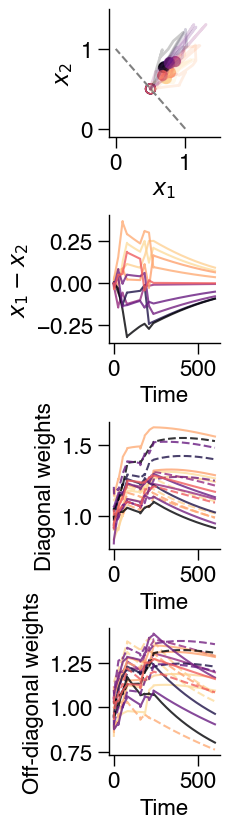

In [4]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 300:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=5,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

In [13]:
import numpy as np
from scipy.integrate import solve_ivp

class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        tau_z=0.5,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
        deriv_sign=1,
    ):
        # Handle constant vs callable input
        if callable(u_func):
            self.u_func = u_func
        else:
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array

        self.reset_func = reset_func
        self.tau = tau
        self.tau_z = tau_z
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        self.deriv_sign = deriv_sign

        if w_11 is None:
            w_11 = 1.5
        if w_22 is None:
            w_22 = 1.5
        if w_12 is None:
            w_12 = 0.5 + np.random.normal(scale=weight_perturbation)
        if w_21 is None:
            w_21 = 0.5 + np.random.normal(scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                            [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = np.array(w_inh)

        self.x0 = np.clip(
            np.array([x1_init, x2_init]) +
            np.random.normal(scale=noise_std, size=2),
            0, 1
        )

        # Initial low-pass filtered z
        self.zlp0 = np.zeros(2)

    def system_dynamics(self, t, state):
        """
        state = [x1, x2, zlp1, zlp2, w11, w12, w21, w22]
        """
        x1, x2, zlp1, zlp2, w11, w12, w21, w22 = state

        x = np.clip(np.array([x1, x2]), 0, None)
        z_lp = np.array([zlp1, zlp2])

        W = np.array([[w11, w12],
                      [w21, w22]])

        w_inh = np.array([
            [self.w_inh[0], self.w_inh[0]],
            [self.w_inh[1], self.w_inh[1]]
        ])

        u_t = np.array(self.u_func(t))

        # Neural dynamics
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where((x <= 0) & (dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt

        # Raw z
        z = np.maximum(u_t - 0.5, 0)

        # Low-pass filtered z
        dzlp_dt = (z - z_lp) / self.tau_z
        dzlp1_dt, dzlp2_dt = dzlp_dt

        # Learning
        lr = self.learning_rate

        dw12_dt = lr * (
            np.clip((z[0] - z_lp[0]), 0, None) * x[1] *
            (self.alpha * z[0] - np.clip((dx1_dt - dx2_dt)/dt, -10, 10))
        )

        dw21_dt = lr * (
            np.clip((z[1] - z_lp[1]), 0, None) * x[0] *
            (self.alpha * z[1] - np.clip((dx2_dt - dx1_dt)/dt, -10, 10))
        )

        dw11_dt = 0.0
        dw22_dt = 0.0

        # if (z[0] - z_lp[0]) > 0:
        #     print(z[0], z_lp[0])
        #     print(self.alpha * z[0], np.clip((dx1_dt - dx2_dt)/dt, -10, 10), self.alpha * z[0] - np.clip((dx1_dt - dx2_dt)/dt, -10, 10))
            

        return [
            dx1_dt,
            dx2_dt,
            dzlp1_dt,
            dzlp2_dt,
            dw11_dt,
            dw12_dt,
            dw21_dt,
            dw22_dt,
        ]

    def simulate(self, t_span, dt=0.002):
        t_eval = np.arange(t_span[0], t_span[1], dt)

        initial_state = [
            self.x0[0],
            self.x0[1],
            self.zlp0[0],
            self.zlp0[1],
            self.W0[0, 0],
            self.W0[0, 1],
            self.W0[1, 0],
            self.W0[1, 1],
        ]

        sol = solve_ivp(
            fun=self.system_dynamics,
            t_span=t_span,
            y0=initial_state,
            method="RK23",
            t_eval=t_eval,
            atol=1e-7,
            rtol=1e-7,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        x1, x2 = sol.y[0], sol.y[1]
        zlp1, zlp2 = sol.y[2], sol.y[3]
        w11, w12, w21, w22 = sol.y[4], sol.y[5], sol.y[6], sol.y[7]

        u_history = np.array([self.u_func(t) for t in sol.t])

        return sol.t, x1, x2, zlp1, zlp2, w11, w12, w21, w22, u_history

In [4]:
def run_simulation_chunked(
    u_funcs=None,
    reset_funcs=None,
    x1_init_values=None,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_total=(0, 200),
    chunk_size=150,
    weight_perturbation=0,
    color_by=None,
    noise_std=0,
    tau=2,
    save_path=None,
    make_cbar=False,
    w_inh=np.array([1, 1]),
    cbar_label=None,
    y_lim_1=None,
    y_lim_2=None,
    y_lim_3=None,
    y_lim_4=None,
    width=1,
    deriv_sign=1,
):
    if seed:
        np.random.seed(seed)

    if x1_init_values is None:
        x1_init_values = np.clip(np.linspace(0.05, 0.95, 10), 0, 1)

    x2_init_values = 1 - x1_init_values

    if u_funcs is None:
        u_funcs = [lambda t: [0.5, 0.5]] * len(x1_init_values)
    if reset_funcs is None:
        reset_funcs = [lambda t: 0] * len(x1_init_values)

    cmap = sns.color_palette("magma", as_cmap=True)
    colors = cmap(0.5) if color_by is None else cmap(0.5 * (1 + color_by / np.abs(color_by).max()))

    t_start, t_end = t_total
    n_chunks = int(np.ceil((t_end - t_start) / chunk_size))

    # Set up the plot - now 4 rows, 1 column
    scale = 0.6
    fig, axes = plt.subplots(4, 1, figsize=(4 * scale * width, 14 * scale))

    all_results = []

    print(f"Running {n_chunks} chunks of {chunk_size} time units each...")

    for i, (x1_init, x2_init, color) in enumerate(zip(x1_init_values, x2_init_values, colors)):

        print(f" Simulating condition {i+1}/{len(x1_init_values)}...")
        
        system = LinearSystem(
            u_funcs[i], reset_funcs[i], tau,
            x1_init=x1_init,
            x2_init=x2_init,
            noise_std=noise_std,
            weight_perturbation=weight_perturbation,
            learning_rate=learning_rate,
            homeo_rate=homeo_rate,
            alpha=alpha,
            w_inh=w_inh,
            deriv_sign=deriv_sign,
        )

        system.zlp0 = np.zeros(2)

        all_t, all_w11, all_w12, all_w21, all_w22 = [], [], [], [], []

        for chunk_idx in range(n_chunks):
            chunk_start = t_start + chunk_idx * chunk_size
            chunk_end = min(chunk_start + chunk_size, t_end)

            t, x1, x2, zlp1, zlp2, w11, w12, w21, w22, _ = system.simulate(
                (chunk_start, chunk_end)
            )

            all_t.append(t)
            all_w11.append(w11)
            all_w12.append(w12)
            all_w21.append(w21)
            all_w22.append(w22)

            system.x0 = np.array([x1[-1], x2[-1]])
            system.zlp0 = np.array([zlp1[-1], zlp2[-1]])
            system.W0 = np.array([[w11[-1], w12[-1]],
                                  [w21[-1], w22[-1]]])

            if chunk_idx == n_chunks - 1:
                last_t, last_x1, last_x2 = t, x1, x2

        all_t = np.concatenate(all_t)
        all_w11 = np.concatenate(all_w11)
        all_w12 = np.concatenate(all_w12)
        all_w21 = np.concatenate(all_w21)
        all_w22 = np.concatenate(all_w22)

        axes[0].plot(last_t, last_x1 - last_x2, color=color)
        axes[1].plot(all_t, all_w11, color=color)
        axes[1].plot(all_t, all_w22, '--', color=color)
        axes[2].plot(all_t, all_w21, color=color)
        axes[2].plot(all_t, all_w12, '--', color=color)
        axes[3].plot(all_t, (all_w11 - w_inh[0]) - (all_w21 - w_inh[1]), color=color)
        axes[3].plot(all_t, (all_w22 - w_inh[1]) - (all_w12 - w_inh[0]), '--', color=color)

        # # Configure all subplots
        # axes[0].set_xlabel(r'$x_1$')
        # axes[0].set_ylabel(r'$x_2$')
        # # axes[0].grid(True, alpha=0.3)
        # axes[0].set_xlim(-0.1, 1.5)
        # if not y_lim_1:
        #     axes[0].set_ylim(-0.1, 1.5)
        # else:
        #     axes[0].set_ylim(*y_lim_1)
        
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel(r'$x_1 - x_2$')
        
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Diagonal weights')
        
        axes[2].set_xlabel('Time')
        axes[2].set_ylabel('Off-diagonal weights')

        all_results.append((last_t, last_x1, last_x2, all_t, all_w11, all_w12, all_w21, all_w22))

    format_plot(axes, ticklabelsize=16, axislabelsize=16)
    plt.tight_layout()
    plt.show()

    if save_path:
        fig.savefig(save_path + ".png")
        fig.savefig(save_path + ".svg")

    return all_results, fig


Running 50 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


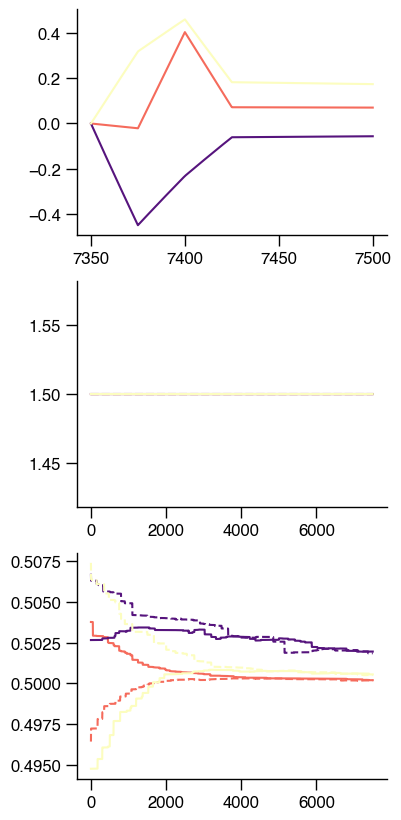

In [44]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 50
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 50,
    alpha=1/dt,
    seed=13,
    weight_perturbation=0.005,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 200 chunks of 150 time units each...
 Simulating condition 1/10...
 Simulating condition 2/10...
 Simulating condition 3/10...
 Simulating condition 4/10...
 Simulating condition 5/10...
 Simulating condition 6/10...
 Simulating condition 7/10...
 Simulating condition 8/10...
 Simulating condition 9/10...
 Simulating condition 10/10...


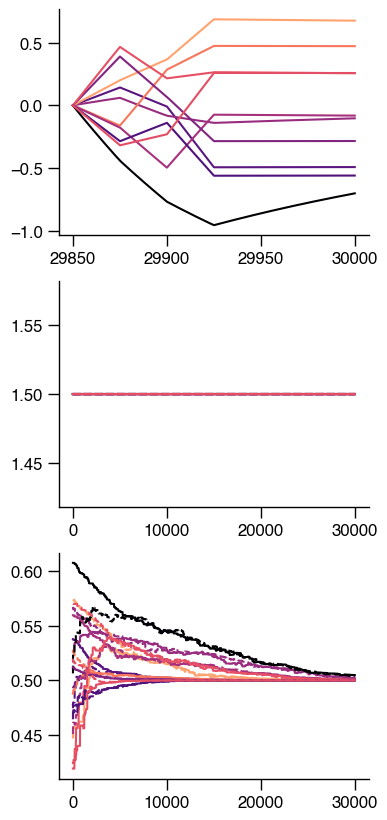

In [48]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 200
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 1 chunks of 150 time units each...
  Simulating condition 1/10...
  Simulating condition 2/10...
  Simulating condition 3/10...
  Simulating condition 4/10...
  Simulating condition 5/10...
  Simulating condition 6/10...
  Simulating condition 7/10...
  Simulating condition 8/10...
  Simulating condition 9/10...
  Simulating condition 10/10...


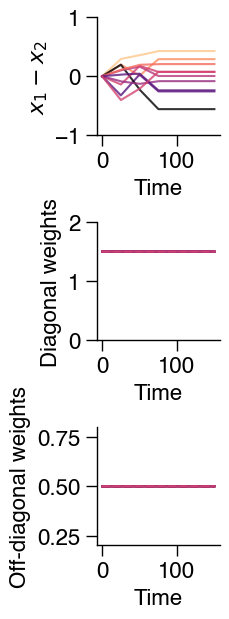

In [23]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                # if np.random.rand() > 0.5:
                #     u_block[0] = 0
                # else:
                #     u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 1
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    alpha=0.01,
    seed=13,
    weight_perturbation=0,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 1 chunks of 150 time units each...
  Simulating condition 1/10...
  Simulating condition 2/10...
  Simulating condition 3/10...
  Simulating condition 4/10...
  Simulating condition 5/10...
  Simulating condition 6/10...
  Simulating condition 7/10...
  Simulating condition 8/10...
  Simulating condition 9/10...
  Simulating condition 10/10...


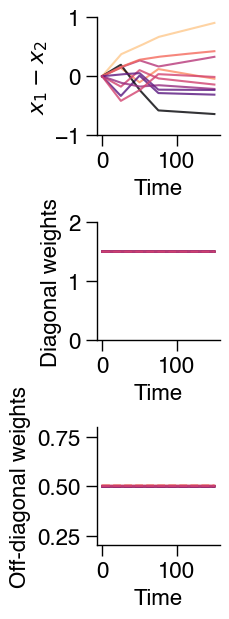

In [25]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                # if np.random.rand() > 0.5:
                #     u_block[0] = 0
                # else:
                #     u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 1
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    alpha=0.01,
    seed=13,
    weight_perturbation=0.002,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

In [6]:
import numpy as np
from scipy.integrate import solve_ivp

class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        tau_z=0.5,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
        deriv_sign=1,
    ):
        # Handle constant vs callable input
        if callable(u_func):
            self.u_func = u_func
        else:
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array

        self.reset_func = reset_func
        self.tau = tau
        self.tau_z = tau_z
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        self.deriv_sign = deriv_sign

        if w_11 is None:
            w_11 = 1.5
        if w_22 is None:
            w_22 = 1.5
        if w_12 is None:
            w_12 = 0.5 + np.random.normal(scale=weight_perturbation)
        if w_21 is None:
            w_21 = 0.5 + np.random.normal(scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                            [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = np.array(w_inh)

        self.x0 = np.clip(
            np.array([x1_init, x2_init]) +
            np.random.normal(scale=noise_std, size=2),
            0, 1
        )

        # Initial low-pass filtered z
        self.zlp0 = np.zeros(2)

    def system_dynamics(self, t, state):
        """
        state = [x1, x2, zlp1, zlp2, w11, w12, w21, w22]
        """
        x1, x2, zlp1, zlp2, w11, w12, w21, w22 = state

        x = np.clip(np.array([x1, x2]), 0, None)
        z_lp = np.array([zlp1, zlp2])

        W = np.array([[w11, w12],
                      [w21, w22]])

        w_inh = np.array([
            [self.w_inh[0], self.w_inh[0]],
            [self.w_inh[1], self.w_inh[1]]
        ])

        u_t = np.array(self.u_func(t))

        # Neural dynamics
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where((x <= 0) & (dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt

        # Raw z
        z = np.maximum(u_t - 0.5, 0)

        # Low-pass filtered z
        dzlp_dt = (z - z_lp) / self.tau_z
        dzlp1_dt, dzlp2_dt = dzlp_dt

        # Learning
        lr = self.learning_rate

        dw12_dt = lr * (
            np.clip((z[0] - z_lp[0]), 0, None) * x[1] *
            (self.alpha * z[0] - np.clip(dx1_dt/dt, -10, 10))
        )

        dw21_dt = lr * (
            np.clip((z[1] - z_lp[1]), 0, None) * x[0] *
            (self.alpha * z[1] - np.clip(dx2_dt/dt, -10, 10))
        )

        dw11_dt = 0.0
        dw22_dt = 0.0

        # if (z[0] - z_lp[0]) > 0:
        #     print(z[0], z_lp[0])
        #     print(self.alpha * z[0], np.clip((dx1_dt - dx2_dt)/dt, -10, 10), self.alpha * z[0] - np.clip((dx1_dt - dx2_dt)/dt, -10, 10))
            

        return [
            dx1_dt,
            dx2_dt,
            dzlp1_dt,
            dzlp2_dt,
            dw11_dt,
            dw12_dt,
            dw21_dt,
            dw22_dt,
        ]

    def simulate(self, t_span, dt=0.002):
        t_eval = np.arange(t_span[0], t_span[1], dt)

        initial_state = [
            self.x0[0],
            self.x0[1],
            self.zlp0[0],
            self.zlp0[1],
            self.W0[0, 0],
            self.W0[0, 1],
            self.W0[1, 0],
            self.W0[1, 1],
        ]

        sol = solve_ivp(
            fun=self.system_dynamics,
            t_span=t_span,
            y0=initial_state,
            method="RK23",
            t_eval=t_eval,
            atol=1e-7,
            rtol=1e-7,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        x1, x2 = sol.y[0], sol.y[1]
        zlp1, zlp2 = sol.y[2], sol.y[3]
        w11, w12, w21, w22 = sol.y[4], sol.y[5], sol.y[6], sol.y[7]

        u_history = np.array([self.u_func(t) for t in sol.t])

        return sol.t, x1, x2, zlp1, zlp2, w11, w12, w21, w22, u_history

Running 40 chunks of 150 time units each...
 Simulating condition 1/10...
 Simulating condition 2/10...
 Simulating condition 3/10...
 Simulating condition 4/10...
 Simulating condition 5/10...
 Simulating condition 6/10...
 Simulating condition 7/10...
 Simulating condition 8/10...
 Simulating condition 9/10...
 Simulating condition 10/10...


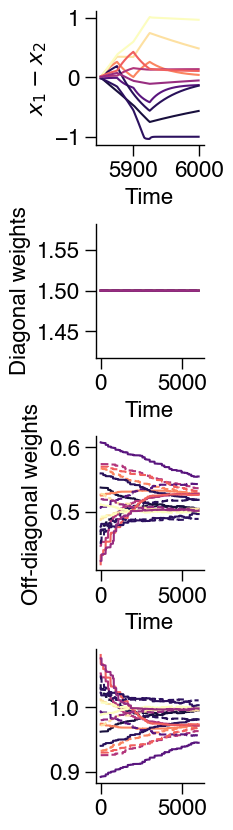

In [27]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 40
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 200 chunks of 150 time units each...
 Simulating condition 1/5...
 Simulating condition 2/5...
 Simulating condition 3/5...
 Simulating condition 4/5...
 Simulating condition 5/5...


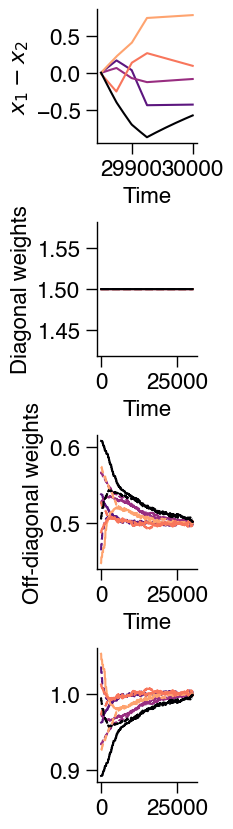

In [38]:
np.random.seed(141)
dt = 0.002
n = 5
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 200
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 300 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


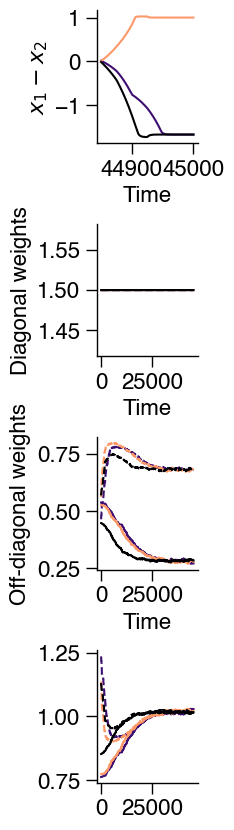

In [5]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 300
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
    w_inh=np.array([1, 0.8]),
)

In [17]:
w_inh = np.array([1, 0.8])
cut = (500 * 150 * 250, 500 * 150 * 250 + 10)
for (last_t, last_x1, last_x2, all_t, all_w11, all_w12, all_w21, all_w22) in res:
    print((all_w22[cut[0]:cut[1]] - w_inh[1]) - (all_w12[cut[0]:cut[1]] - w_inh[0]))
    print((all_w22[-10:]  - w_inh[1]) - (all_w12[-10:] - w_inh[0]))

[1.01421499 1.01421499 1.01421499 1.01421499 1.01421499 1.01421499
 1.01421499 1.01421499 1.01421499 1.01421499]
[1.01868249 1.01868249 1.01868249 1.01868249 1.01868249 1.01868249
 1.01868249 1.01868249 1.01868249 1.01868249]
[1.02089243 1.02090745 1.02092241 1.02093731 1.02095215 1.02096693
 1.02098165 1.02099632 1.02101092 1.02102547]
[1.01824829 1.01824829 1.01824829 1.01824829 1.01824829 1.01824829
 1.01824829 1.01824829 1.01824829 1.01824829]
[1.01731843 1.01733435 1.01735019 1.01736598 1.0173817  1.01739736
 1.01741296 1.01742849 1.01744397 1.01745938]
[1.01687735 1.01687735 1.01687735 1.01687735 1.01687735 1.01687735
 1.01687735 1.01687735 1.01687735 1.01687735]


Running 300 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


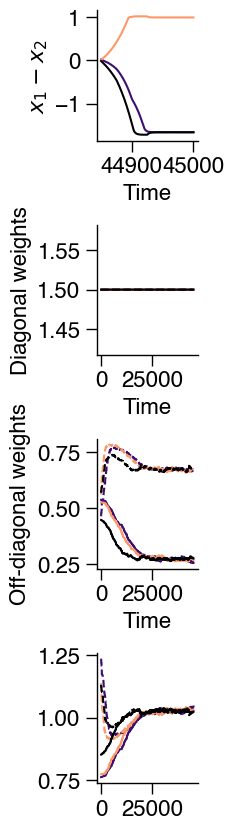

In [7]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 300
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.65,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
    w_inh=np.array([1, 0.8]),
)

In [9]:
w_inh = np.array([1, 0.8])
cut = (500 * 150 * 250, 500 * 150 * 250 + 10)
for (last_t, last_x1, last_x2, all_t, all_w11, all_w12, all_w21, all_w22) in res:
    # print((all_w22[cut[0]:cut[1]] - w_inh[1]) - (all_w12[cut[0]:cut[1]] - w_inh[0]))
    print((all_w22[-10:]  - w_inh[1]) - (all_w12[-10:] - w_inh[0]))

[1.03136387 1.03136387 1.03136387 1.03136387 1.03136387 1.03136387
 1.03136387 1.03136387 1.03136387 1.03136387]
[1.0268405 1.0268405 1.0268405 1.0268405 1.0268405 1.0268405 1.0268405
 1.0268405 1.0268405 1.0268405]
[1.0241896 1.0241896 1.0241896 1.0241896 1.0241896 1.0241896 1.0241896
 1.0241896 1.0241896 1.0241896]


Running 300 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


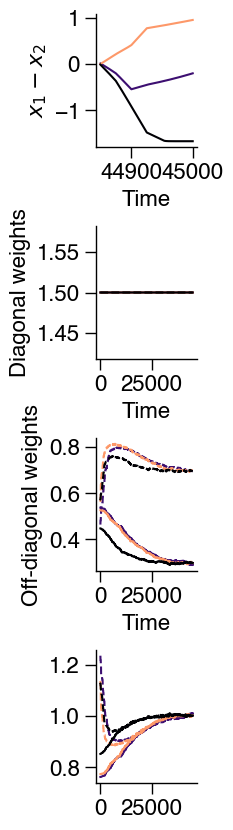

In [11]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 300
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.85,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
    w_inh=np.array([1, 0.8]),
)

In [12]:
w_inh = np.array([1, 0.8])
cut = (500 * 150 * 250, 500 * 150 * 250 + 10)
for (last_t, last_x1, last_x2, all_t, all_w11, all_w12, all_w21, all_w22) in res:
    # print((all_w22[cut[0]:cut[1]] - w_inh[1]) - (all_w12[cut[0]:cut[1]] - w_inh[0]))
    print((all_w22[-10:]  - w_inh[1]) - (all_w12[-10:] - w_inh[0]))

[1.00229937 1.00229937 1.00229937 1.00229937 1.00229937 1.00229937
 1.00229937 1.00229937 1.00229937 1.00229937]
[1.0020454 1.0020454 1.0020454 1.0020454 1.0020454 1.0020454 1.0020454
 1.0020454 1.0020454 1.0020454]
[1.00408367 1.00408367 1.00408367 1.00408367 1.00408367 1.00408367
 1.00408367 1.00408367 1.00408367 1.00408367]


Running 1 chunks of 150 time units each...
 Simulating condition 1/5...
 Simulating condition 2/5...
 Simulating condition 3/5...
 Simulating condition 4/5...
 Simulating condition 5/5...


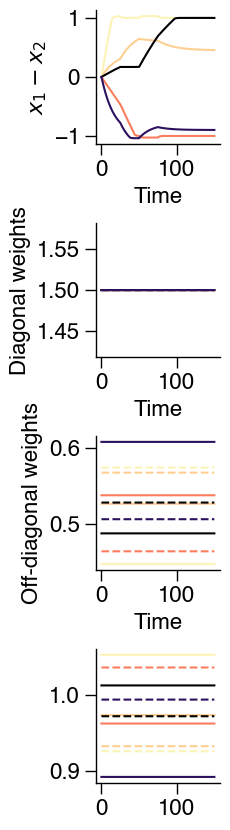

In [6]:
np.random.seed(141)
dt = 0.002
n = 5
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 1
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

In [ ]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 200
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 200 chunks of 150 time units each...
 Simulating condition 1/10...
 Simulating condition 2/10...
 Simulating condition 3/10...
 Simulating condition 4/10...
 Simulating condition 5/10...
 Simulating condition 6/10...
 Simulating condition 7/10...


Running 200 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


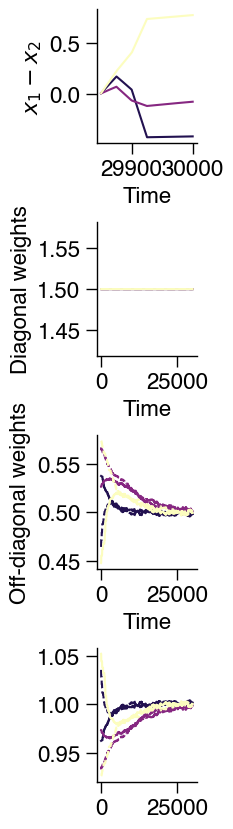

In [28]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 200
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

Running 1 chunks of 150 time units each...
 Simulating condition 1/10...
 Simulating condition 2/10...
 Simulating condition 3/10...
 Simulating condition 4/10...
 Simulating condition 5/10...
 Simulating condition 6/10...
 Simulating condition 7/10...
 Simulating condition 8/10...
 Simulating condition 9/10...
 Simulating condition 10/10...


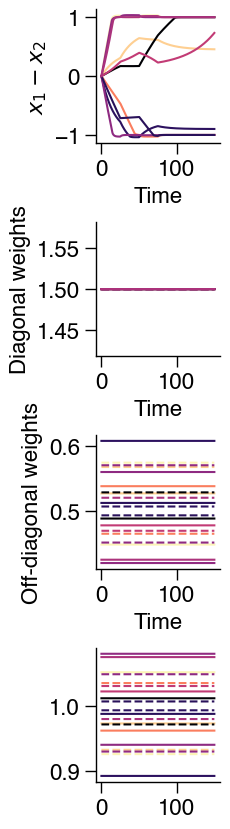

In [30]:
np.random.seed(141)
dt = 0.002
n = 10
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 1
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)

In [34]:
import numpy as np
from scipy.integrate import solve_ivp

class LinearSystem:
    def __init__(
        self,
        u_func,
        reset_func,
        tau=1.0,
        tau_z=0.5,
        x1_init=0.5,
        x2_init=0.5,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
        w_inh=None,
        deriv_sign=1,
    ):
        # Handle constant vs callable input
        if callable(u_func):
            self.u_func = u_func
        else:
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array

        self.reset_func = reset_func
        self.tau = tau
        self.tau_z = tau_z
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        self.deriv_sign = deriv_sign

        if w_11 is None:
            w_11 = 1.5 + np.random.normal(scale=weight_perturbation)
        if w_22 is None:
            w_22 = 1.5 + np.random.normal(scale=weight_perturbation)
        if w_12 is None:
            w_12 = 0.5 + np.random.normal(scale=weight_perturbation)
        if w_21 is None:
            w_21 = 0.5 + np.random.normal(scale=weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                            [w_21, w_22]])

        if w_inh is None:
            self.w_inh = np.array([1, 1])
        else:
            self.w_inh = np.array(w_inh)

        self.x0 = np.clip(
            np.array([x1_init, x2_init]) +
            np.random.normal(scale=noise_std, size=2),
            0, 1
        )

        # Initial low-pass filtered z
        self.zlp0 = np.zeros(2)

    def system_dynamics(self, t, state):
        """
        state = [x1, x2, zlp1, zlp2, w11, w12, w21, w22]
        """
        x1, x2, zlp1, zlp2, w11, w12, w21, w22 = state

        x = np.clip(np.array([x1, x2]), 0, None)
        z_lp = np.array([zlp1, zlp2])

        W = np.array([[w11, w12],
                      [w21, w22]])

        w_inh = np.array([
            [self.w_inh[0], self.w_inh[0]],
            [self.w_inh[1], self.w_inh[1]]
        ])

        u_t = np.array(self.u_func(t))

        # Neural dynamics
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where((x <= 0) & (dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt

        # Raw z
        z = np.maximum(u_t - 0.5, 0)

        # Low-pass filtered z
        dzlp_dt = (z - z_lp) / self.tau_z
        dzlp1_dt, dzlp2_dt = dzlp_dt

        # Learning
        lr = self.learning_rate

        dw11_dt = lr * (
            np.clip((z[0] - z_lp[0]), 0, None) * x[0] *
            (self.alpha * z[0] - np.clip(dx1_dt/dt, -10, 10))
        ) + self.homeo_rate * (2 - w11 - w21)

        dw12_dt = lr * (
            np.clip((z[0] - z_lp[0]), 0, None) * x[1] *
            (self.alpha * z[0] - np.clip(dx1_dt/dt, -10, 10))
        ) + self.homeo_rate * (2 - w22 - w12)

        dw21_dt = lr * (
            np.clip((z[1] - z_lp[1]), 0, None) * x[0] *
            (self.alpha * z[1] - np.clip(dx2_dt/dt, -10, 10))
        ) + self.homeo_rate * (2 - w11 - w21)

        dw22_dt = lr * (
            np.clip((z[1] - z_lp[1]), 0, None) * x[1] *
            (self.alpha * z[1] - np.clip(dx2_dt/dt, -10, 10))
        ) + self.homeo_rate * (2 - w22 - w12)

        return [
            dx1_dt,
            dx2_dt,
            dzlp1_dt,
            dzlp2_dt,
            dw11_dt,
            dw12_dt,
            dw21_dt,
            dw22_dt,
        ]

    def simulate(self, t_span, dt=0.002):
        t_eval = np.arange(t_span[0], t_span[1], dt)

        initial_state = [
            self.x0[0],
            self.x0[1],
            self.zlp0[0],
            self.zlp0[1],
            self.W0[0, 0],
            self.W0[0, 1],
            self.W0[1, 0],
            self.W0[1, 1],
        ]

        sol = solve_ivp(
            fun=self.system_dynamics,
            t_span=t_span,
            y0=initial_state,
            method="RK23",
            t_eval=t_eval,
            atol=1e-7,
            rtol=1e-7,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        x1, x2 = sol.y[0], sol.y[1]
        zlp1, zlp2 = sol.y[2], sol.y[3]
        w11, w12, w21, w22 = sol.y[4], sol.y[5], sol.y[6], sol.y[7]

        u_history = np.array([self.u_func(t) for t in sol.t])

        return sol.t, x1, x2, zlp1, zlp2, w11, w12, w21, w22, u_history

Running 60 chunks of 150 time units each...
 Simulating condition 1/3...
 Simulating condition 2/3...
 Simulating condition 3/3...


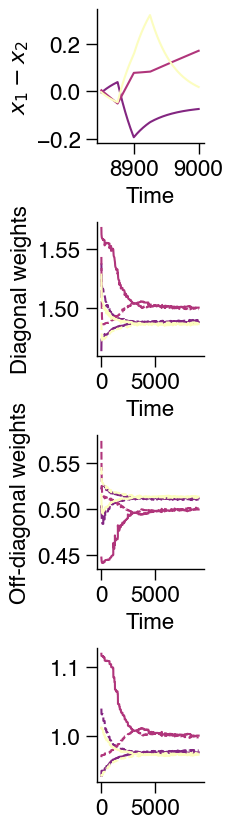

In [35]:
np.random.seed(141)
dt = 0.002
n = 3
x1s = np.ones((n)) * 0.5

# Your existing make_u_funcs code stays the same
def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])
    funcs = []
    all_inps = []
    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        dc_inp = np.zeros((2, len(t)))
        for t_p in np.arange(0, t.max(), block_len):
            if (t_p % 150) < 75:
                u_block = np.random.rand(2)
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len)/dt)] = 0.02 * u_block[:, None]
        for t_int_start in np.arange(0, t.max(), 150):
            if t_int_start + 150 < t.max():
                dc_inp[:, int(t_int_start/dt):int((t_int_start + 125)/dt)] = 0.5
                dc_inp[:, int((t_int_start + 145)/dt):int((t_int_start + 150)/dt)] = 0.5
            else:
                dc_inp[:, int(t_int_start/dt):] = 0.5
        
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + dc_inp))
    return funcs, all_inps

t_max = 150 * 60
u_funcs, all_inps = make_u_funcs(n, np.arange(0, t_max, dt), dt=dt)
    
res, fig = run_simulation_chunked(
    homeo_rate=0.02,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=dt * 100,
    alpha=1/dt * 0.75,
    seed=13,
    weight_perturbation=0.05,
    t_total=(0, t_max),
    chunk_size=150,  # Process in 150 time unit chunks
    color_by=np.array([(inp[0, (t_max - 150) * 500:t_max * 500].sum() - inp[1, (t_max - 150) * 500:t_max * 500].sum()) for inp in all_inps]),
    noise_std=0,
    save_path='figures/handbuilt_rules/2d_handbuilt_antihebbian_presyn_integration',
    y_lim_2=(-1, 1),
    y_lim_3=(0, 2),
    y_lim_4=(0.2, 0.8),
    width=1,
)